In [1]:
import numpy as np
import pandas as pd

In [2]:
df = pd.read_csv('~/Teaching/data/Advertising.csv')
df.head()

,Unnamed: 0,TV,Radio,Newspaper,Sales
0,1,230.1,37.8,69.2,22.1
1,2,44.5,39.3,45.1,10.4
2,3,17.2,45.9,69.3,9.3
3,4,151.5,41.3,58.5,18.5
4,5,180.8,10.8,58.4,12.9


In [3]:
df.iloc[:5,[1,-1]]

,TV,Sales
0,230.1,22.1
1,44.5,10.4
2,17.2,9.3
3,151.5,18.5
4,180.8,12.9


In [4]:
import matplotlib.pyplot as plt

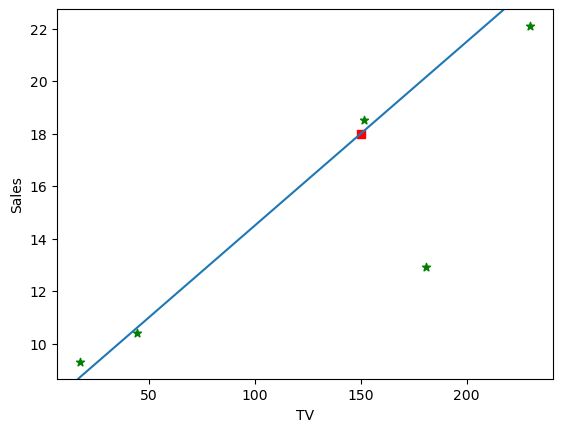

In [8]:
plt.scatter(df.iloc[:5, 1], df.iloc[:5,-1], marker = '*', color = 'g')
plt.xlabel(df.columns[1])
plt.ylabel(df.columns[-1])
plt.axline((150, 18), slope = 0.07)
plt.scatter(150,18, marker = 's', color ='r')

In [9]:
x = df.iloc[:5, 1].values
y = df.iloc[:5, -1].values

In [10]:
x

array([230.1,  44.5,  17.2, 151.5, 180.8])

In [11]:
type(x)

numpy.ndarray

In [12]:
x ** 2

array([52946.01,  1980.25,   295.84, 22952.25, 32688.64])

In [14]:
A = (x ** 2).sum()

In [15]:
b = 7.5
#B 

In [16]:
y

array([22.1, 10.4,  9.3, 18.5, 12.9])

In [17]:
b - y

array([-14.6,  -2.9,  -1.8, -11. ,  -5.4])

In [18]:
B = 2 * (x * (b - y)).sum()

In [20]:
m_opt = - B / (2 * A)
m_opt

np.float64(0.05558473571748337)

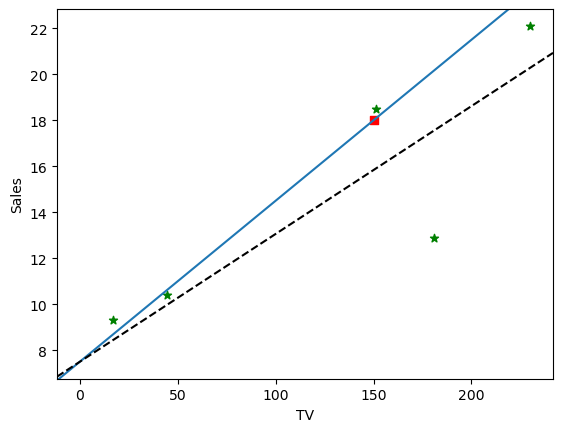

In [21]:
plt.scatter(df.iloc[:5, 1], df.iloc[:5,-1], marker = '*', color = 'g')
plt.xlabel(df.columns[1])
plt.ylabel(df.columns[-1])
plt.axline((150, 18), slope = 0.07)
plt.scatter(150,18, marker = 's', color ='r')
plt.axline((0, b), slope = m_opt, color = 'k', linestyle = '--')
plt.show()

In [23]:
df.iloc[:5, [1,-1]]

,TV,Sales
0,230.1,22.1
1,44.5,10.4
2,17.2,9.3
3,151.5,18.5
4,180.8,12.9


In [25]:
df['pred'] = b + m_opt * df['TV']
df.iloc[:5,[1,-2,-1]]

,TV,Sales,pred
0,230.1,22.1,20.290048
1,44.5,10.4,9.973521
2,17.2,9.3,8.456057
3,151.5,18.5,15.921087
4,180.8,12.9,17.549720


In [26]:
from scipy.optimize import minimize

In [27]:
def obj(w):
    m, b = w
    x = df.iloc[:5, 1].values
    y = df.iloc[:5, -2].values
    pred = m * x + b

    return ((pred - y) ** 2).mean()

In [28]:
res = minimize(obj, x0 = [0, 0])

In [29]:
res.x

array([0.0517618 , 8.17909235])